# NYC Yellow Taxi Fleet Deployment and Revenue Optimization
### Notebook 02: Predictive modeling and prescriptive deployment analysis

**Course:** DSS142P | **Group 1:** Abad, Aguirre, Galit, Ibañez, Risma, Vicente

**Input:** `data/NYC_Taxi_ABT.parquet`, built by `01_abt.ipynb` (3,757,895 valid trips, Jan–Nov 2025)
**Run order:** `01_abt.ipynb` → this notebook

## Business context

New York City yellow taxi drivers earn only while a passenger is on board, and not every dollar a passenger pays stays with the driver. Each trip carries pass-through charges: the NYS congestion surcharge ($2.50), the MTA tax ($0.50), the improvement surcharge ($1.00), the airport fee ($1.75), and, since **January 5, 2025**, the MTA Congestion Relief Zone fee ($0.75 per yellow-taxi trip in Manhattan's Central Business District). Because these charges are flat per trip, they take a larger share of short, low-fare trips: about 31% of gross revenue on fares under $10, versus about 6% on fares of $40 or more (`01_abt.ipynb`, §6).

How much a driver keeps per occupied hour also depends on **where** and **when** they pick up passengers. Some zones and hours produce longer, better-paying trips, while traffic congestion stretches trip time without raising the fare proportionally. A fleet that positions its drivers well can earn more from the same driving hours.

## Business question and problem

**Business question.** *How can the fleet operator optimize shift scheduling and zone positioning to maximize driver hourly earnings and fleet revenue in the face of 2025 congestion fees?*

**Problem.** The fleet needs to know which pickup zones, days and hours to prioritize for driver deployment to maximize **net revenue per occupied driving hour**, and how congestion fees, trip length, fare level and traffic conditions affect that revenue efficiency.

**Output.** A decision-support model that predicts net revenue per occupied hour for each pickup zone × day × hour, converted into a **ranked deployment table**, a **fee-based fare and trip-length rule**, and **congestion thresholds** for deprioritizing zones.

| Item | Definition |
|---|---|
| Unit of analysis | Pickup zone × date × pickup hour, aggregated from trips |
| Target | `net_revenue_per_hour` = Σ net revenue ÷ Σ occupied minutes × 60, per zone-hour |
| Net revenue | Gross fare total − (CBD fee + congestion surcharge + airport fee + MTA tax + improvement surcharge) − tolls (ABT decision D1) |

## Analytical questions

1. **AQ1: Shift scheduling and zone positioning.** Which day-of-week and pickup-hour combinations should the fleet prioritize for driver deployment based on trip demand and revenue generated per occupied driving hour, and how does this vary across pickup zones?
2. **AQ2: Congestion-fee impact and thresholds.** To what extent do 2025 congestion fees reduce gross trip revenue across different fare tiers and pickup zones, and what trip-length thresholds or minimum fare should be applied to guide drivers to optimal zone-positioning to reduce revenue loss?
3. **AQ3: Congestion tipping points.** At what levels of traffic congestion do pickup zones begin to show lower net take per occupied driving hour, and which zones should the fleet deprioritize when congestion becomes too costly?

| AQ | Method | Output (section) |
|---|---|---|
| AQ1 | Champion model predictions per zone × day × hour, combined with expected demand | Ranked deployment table (§8.1) |
| AQ2 | Grouped analysis of fee share and net $/hr by fare tier, trip-length tier and zone (trip-level ABT) | Minimum-fare / trip-length rule and highest-burden zones (§8.2) |
| AQ3 | Champion model response to lagged traffic speed, overall and per zone | Speed thresholds and zones to deprioritize (§8.3) |

## Methodology

**Approach:** supervised regression + prescriptive ranking, following the comparative structure of Kankanamge et al. (2019), which compares XGBoost with SVR and a neural network on large-scale taxi data.

1. **Data (§2–3).** Load the validated ABT, confirm its structure, and explore the target by hour, day, zone, demand and traffic.
2. **Aggregation and features (§4).** Aggregate trips to zone × date × hour; build lagged demand, speed and fee-share features. **Leakage rule:** only information available before the hour is used as a predictor.
3. **Validation design (§5).** Expanding-window monthly folds (train on all earlier months, validate on the next month) are used for tuning. October–November 2025 is held out as the final test period and used once.
4. **One procedure for every model (§6).** Naive baseline, XGBoost, SVR and neural network all follow: tune on the folds → refit on all pre-test data → evaluate once on the test period. Preprocessing is fit inside the training data only.
5. **Evaluation (§7).** MAE (primary), RMSE and R²; ranking metrics (overall and within-hour Spearman, Precision@10); a day-level bootstrap confidence interval for each model's improvement over the baseline; and errors by segment (peak/off-peak, trip volume).
6. **Champion selection (§7).** Lowest test MAE, provided its improvement over the baseline is supported by the confidence interval; ranking metrics as supporting evidence.
7. **Interpretation and prescription (§8).** SHAP explanations of the champion, then the AQ1–AQ3 outputs.

### Changes from FA2

| FA2 issue | Fix in this version |
|---|---|
| ABT code, ABT file and model inputs were three different versions | Single rebuilt ABT (`01_abt.ipynb`) with documented findings and checks |
| XGBoost refit on train + validation; other models were not | One procedure for all models, including the baseline |
| Single validation split; MAE rose from validation to test | Expanding-window monthly folds |
| Spearman reported for XGBoost only; no ranking metric for dispatch | Spearman, within-hour Spearman and Precision@10 for every model |
| No uncertainty on the gain over the baseline | Day-level bootstrap confidence intervals |
| Feature importance presented as recommendations | Ranked deployment table, fee rule and congestion thresholds |
| Errors reported only as overall averages | Segment-level error analysis |
| SVR trained on a 25,000-row subsample (47 min) | Kernel-approximated SVR on the full training data |

## 1. Setup

In [5]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

notebook_start = time.perf_counter()

# ---- Paths ----
DATA_DIR = Path("../data")
ABT_PATH = DATA_DIR / "NYC_Taxi_ABT.parquet"
ZONES_PATH = DATA_DIR / "taxi_zone_lookup.csv"
FIG_DIR = Path("../reports/figures")
TABLE_DIR = Path("../reports/tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ---- Reproducibility ----
RANDOM_STATE = 42

# ---- Validation design (see Methodology) ----
TEST_START = pd.Timestamp("2025-10-01")   # Oct–Nov 2025: final test period, used once
VALIDATION_MONTHS = [6, 7, 8, 9]          # each fold trains on all earlier months, validates on this one

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

def save_fig(fig, name):
    """Save a figure to reports/figures for use in the write-up."""
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

for p in [ABT_PATH, ZONES_PATH, FIG_DIR, TABLE_DIR]:
    print(f"{'✓' if p.exists() else '✗ MISSING'}  {p}")

✓  ../data/NYC_Taxi_ABT.parquet
✓  ../data/taxi_zone_lookup.csv
✓  ../reports/figures
✓  ../reports/tables


## 2. Load and validate the ABT
The ABT was validated in `01_abt.ipynb`; these checks confirm the file loaded here is that same, complete version.

In [6]:
abt = pd.read_parquet(ABT_PATH)
print(f"ABT: {len(abt):,} rows × {abt.shape[1]} columns | "
      f"{abt.memory_usage(deep=True).sum() / 1024**3:.2f} GB in memory")

EXPECTED_ROWS = 3_757_895  # output of 01_abt.ipynb §8
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
required = ["tpep_pickup_datetime", "PULocationID", "pickup_hour", "day_of_week", "is_weekend",
            "duration_min", "speed_mph", "trip_distance", "fare_amount", "gross_revenue",
            "total_fees", "congestion_fees", "tolls_amount", "tip_amount", "net_revenue",
            "net_revenue_ex_tip", "net_revenue_per_hour", "fee_impact_pct",
            "congestion_fee_pct", "pickup_date", "pickup_month", "fare_tier", "trip_length_tier"]

recomputed_target = abt["net_revenue"] / abt["duration_min"] * 60
is_cat = lambda col: isinstance(abt[col].dtype, pd.CategoricalDtype)

checks = {
    "Row count matches 01_abt output":     len(abt) == EXPECTED_ROWS,
    "All required columns present":        set(required).issubset(abt.columns),
    "No missing values":                   abt.isna().sum().sum() == 0,
    "Pickups within Jan–Nov 2025":         abt["tpep_pickup_datetime"].between("2025-01-01", "2025-12-01").all(),
    "Target matches its formula":          np.allclose(recomputed_target, abt["net_revenue_per_hour"]),
    "Day order kept (Mon → Sun)":          is_cat("day_of_week") and list(abt["day_of_week"].cat.categories) == DAY_ORDER,
    "Tiers kept as ordered categories":    is_cat("fare_tier") and is_cat("trip_length_tier"),
}
results = pd.Series(checks, name="passed")
display(results.to_frame())
assert results.all(), f"Failed: {list(results[~results].index)}"
print("ABT validated ✓")

ABT: 3,757,895 rows × 37 columns | 0.73 GB in memory


,passed
Row count matches 01_abt output,True
All required columns present,True
No missing values,True
Pickups within Jan–Nov 2025,True
Target matches its formula,True
Day order kept (Mon → Sun),True
Tiers kept as ordered categories,True


ABT validated ✓


In [7]:
monthly = (abt.groupby("pickup_month")
              .agg(trips=("net_revenue", "size"),
                   avg_net_per_hour=("net_revenue_per_hour", "mean"))
              .round(2))
monthly["role"] = np.where(monthly.index >= TEST_START.month, "TEST (held out)",
                  np.where(monthly.index.isin(VALIDATION_MONTHS), "validation fold", "training only"))
monthly

,trips,avg_net_per_hour,role
pickup_month,,,
1,308589,95.87,training only
2,315088,93.20,training only
3,364210,94.57,training only
4,348376,92.34,training only
5,384718,90.09,training only
6,365964,92.41,validation fold
7,328019,91.57,validation fold
8,292101,91.55,validation fold
9,358195,88.48,validation fold


In [8]:
zones = pd.read_csv(ZONES_PATH)
display(zones.head())

abt_zones = abt["PULocationID"].unique()
unnamed = set(abt_zones) - set(zones["LocationID"])
print(f"Pickup zones in ABT: {len(abt_zones)} | zones without a name: {len(unnamed)}")
print("\nPickup zones by borough:")
print(zones[zones["LocationID"].isin(abt_zones)]["Borough"].value_counts().to_string())

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


Pickup zones in ABT: 258 | zones without a name: 0

Pickup zones by borough:
Borough
Queens           69
Manhattan        67
Brooklyn         61
Bronx            43
Staten Island    17
EWR               1


## 3. Exploratory data analysis

**Rule:** EDA uses only the pre-test period (Jan–Sep 2025). The Oct–Nov test period stays unseen until final evaluation, so that it cannot influence modeling choices.

These are trip-level views. Zone-hour views (the unit of analysis) follow the aggregation in §4.

In [9]:
from matplotlib.colors import LinearSegmentedColormap

eda = abt[abt["pickup_date"] < TEST_START]
n_days = eda["pickup_date"].nunique()

print(f"EDA period: {eda['pickup_date'].min():%b %d} – {eda['pickup_date'].max():%b %d, %Y}")
print(f"EDA trips:  {len(eda):,} over {n_days} days")
print(f"Held out:   {len(abt) - len(eda):,} trips (Oct–Nov)")

# Chart colors: one fixed palette for every figure in this notebook
BLUE, ORANGE = "#2a78d6", "#eb6834"   # series 1, series 2
INK = "#0b0b0b"                        # text and reference lines
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])  # light = low, dark = high

EDA period: Jan 01 – Sep 30, 2025
EDA trips:  3,065,260 over 273 days
Held out:   692,635 trips (Oct–Nov)


count    3065260.00
mean          92.17
std           41.25
min            2.05
1%            45.50
5%            56.05
25%           71.15
50%           84.64
75%          103.74
95%          151.98
99%          209.14
99.9%        363.90
max         5889.84


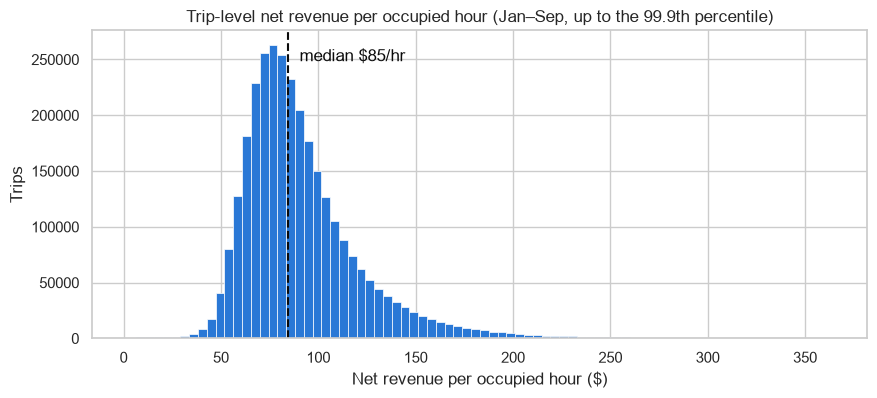

In [10]:
target = eda["net_revenue_per_hour"]
print(target.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]).round(2).to_string())

upper = target.quantile(0.999)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(target[target <= upper], bins=80, color=BLUE, edgecolor="white", linewidth=0.5)
ax.axvline(target.median(), color=INK, linewidth=1.5, linestyle="--")
ax.annotate(f"median ${target.median():.0f}/hr", xy=(target.median(), ax.get_ylim()[1] * 0.9),
            xytext=(8, 0), textcoords="offset points", color=INK)
ax.set(title="Trip-level net revenue per occupied hour (Jan–Sep, up to the 99.9th percentile)",
       xlabel="Net revenue per occupied hour ($)", ylabel="Trips")
save_fig(fig, "eda_target_distribution")
plt.show()

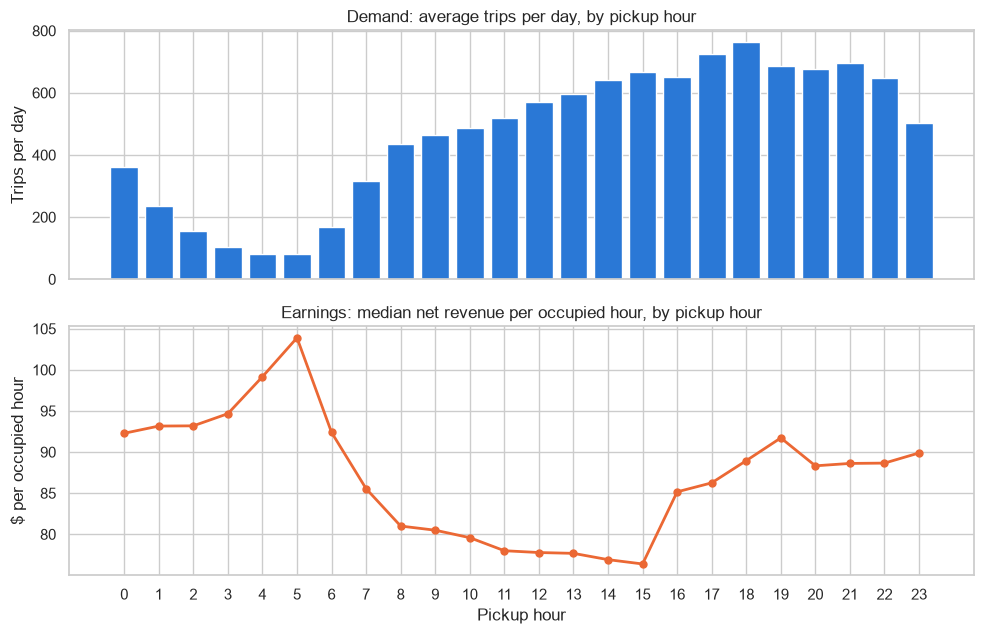

pickup_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
trips_per_day,360.1,235.0,155.7,104.3,79.7,81.5,166.6,316.1,435.8,465.4,485.3,520.0,569.6,596.9,641.5,666.2,652.3,724.8,762.7,686.5,675.8,695.4,647.6,503.2
median_net_per_hour,92.3,93.2,93.2,94.7,99.2,103.9,92.4,85.5,81.0,80.5,79.6,78.0,77.8,77.7,76.9,76.4,85.2,86.3,89.0,91.7,88.3,88.6,88.7,89.9


In [11]:
hourly = eda.groupby("pickup_hour").agg(
    trips=("net_revenue", "size"),
    median_net_per_hour=("net_revenue_per_hour", "median"),
)
hourly["trips_per_day"] = hourly["trips"] / n_days

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)

ax1.bar(hourly.index, hourly["trips_per_day"], color=BLUE, width=0.8)
ax1.set(title="Demand: average trips per day, by pickup hour", ylabel="Trips per day")

ax2.plot(hourly.index, hourly["median_net_per_hour"], color=ORANGE, linewidth=2, marker="o", markersize=5)
ax2.set(title="Earnings: median net revenue per occupied hour, by pickup hour",
        ylabel="$ per occupied hour", xlabel="Pickup hour")
ax2.set_xticks(range(24))

fig.tight_layout()
save_fig(fig, "eda_demand_vs_earnings_by_hour")
plt.show()
display(hourly[["trips_per_day", "median_net_per_hour"]].round(1).T)

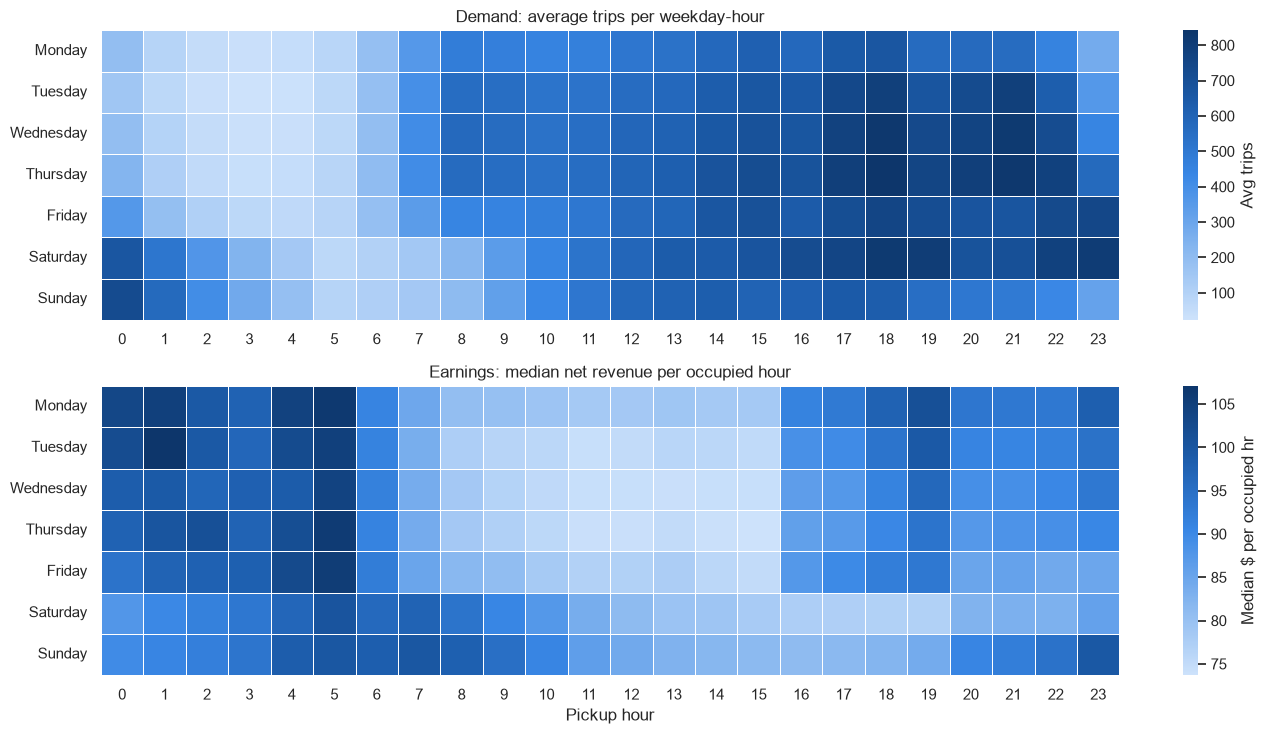

In [12]:
days_per_weekday = eda.groupby("day_of_week", observed=True)["pickup_date"].nunique()

demand_grid = (eda.pivot_table(index="day_of_week", columns="pickup_hour",
                               values="net_revenue", aggfunc="size", observed=True)
                  .div(days_per_weekday, axis=0))          # average trips per weekday-hour
earnings_grid = eda.pivot_table(index="day_of_week", columns="pickup_hour",
                                values="net_revenue_per_hour", aggfunc="median", observed=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 7.5))
sns.heatmap(demand_grid, cmap=SEQ_BLUE, ax=axes[0], linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Avg trips"})
axes[0].set(title="Demand: average trips per weekday-hour", xlabel="", ylabel="")
sns.heatmap(earnings_grid, cmap=SEQ_BLUE, ax=axes[1], linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Median $ per occupied hr"})
axes[1].set(title="Earnings: median net revenue per occupied hour", xlabel="Pickup hour", ylabel="")

fig.tight_layout()
save_fig(fig, "eda_day_hour_heatmaps")
plt.show()